### Модуль отбора признаков для задачи Keyword Spotting. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def load_binary_dataset(npz_path):
    """
    Загружает бинарный датасет из .npz файла.
    Возвращает объединённые данные X_all и целочисленные метки y_int.
    """
    data = np.load(npz_path, allow_pickle=True)
    X_train = data['X_train']
    y_train = data['y_train']
    X_val = data['X_val']
    y_val = data['y_val']
    X_test = data['X_test']
    y_test = data['y_test']

    # Объединяем все данные для анализа признаков
    X_all = np.concatenate([X_train, X_val, X_test], axis=0)
    y_all = np.concatenate([y_train, y_val, y_test], axis=0)

    # Преобразуем one-hot обратно в целочисленные метки
    y_int = np.argmax(y_all, axis=1)

    return X_all, y_int


def feature_selection_binary(temporals, labels, top_n=9):
    """
    Отбирает наиболее дискриминативные признаки для бинарной классификации.

    Аргументы:
        temporals: np.ndarray с признаками (n_samples, n_time, n_features)
        labels: np.ndarray с целевыми метками (n_samples,)
        top_n: int, число выбираемых признаков

    Возвращает:
        X_selected: np.ndarray с топ признаками (n_samples, top_n)
        selected_names: список строк - имена выбранных признаков
        selected_indices: список индексов выбранных признаков
        f_ratios_sorted: список (индекс, F, имя) для всех признаков
    """

    # Усредняем признаки по времени
    X_mean = np.mean(temporals, axis=1)

    # Названия признаков
    feature_names = (
        [f"MFCC_{i}" for i in range(13)]
        + [f"Delta_{i}" for i in range(13)]
        + [f"Delta2_{i}" for i in range(13)]
    )

    unique_labels = np.unique(labels)
    print(f"Уникальные классы: {unique_labels}")
    print(f"Класс 0 (отрицательные): {np.sum(labels == 0)} примеров")
    print(f"Класс 1 (положительные): {np.sum(labels == 1)} примеров")

    # Вычисляем статистики для каждого класса
    means, stds, counts = [], [], []
    for l in unique_labels:
        class_data = X_mean[labels == l]
        means.append(class_data.mean(axis=0))
        stds.append(class_data.std(axis=0))
        counts.append(len(class_data))

    overall_mean = X_mean.mean(axis=0)

    # Вычисляем F-отношение для каждого признака
    f_ratios = []
    for i in range(X_mean.shape[1]):
        # Межклассовая дисперсия
        between = sum(counts[j] * (means[j][i] - overall_mean[i]) ** 2 for j in range(len(unique_labels)))
        # Внутриклассовая дисперсия
        within = sum(counts[j] * (stds[j][i] ** 2) for j in range(len(unique_labels)))
        # F-отношение
        f = between / (within + 1e-6)
        f_ratios.append((i, f, feature_names[i]))

    # Сортируем признаки по F и выбираем лучшие
    f_ratios_sorted = sorted(f_ratios, key=lambda t: t[1], reverse=True)
    selected_indices = [t[0] for t in f_ratios_sorted[:top_n]]
    selected_names = [t[2] for t in f_ratios_sorted[:top_n]]

    # Выводим результаты
    print(f"\nТоп-{top_n} наиболее дискриминативных признаков:")
    print("-" * 60)
    for i, (idx, f, name) in enumerate(f_ratios_sorted[:top_n], 1):
        print(f"{i:2d}. {name:15s} (F = {f:.4f})")

    return X_mean[:, selected_indices], selected_names, selected_indices, f_ratios_sorted


def create_reduced_dataset(original_npz_path, output_npz_path, selected_indices):
    """
    Создаёт новый датасет только с отобранными признаками.

    Аргументы:
        original_npz_path: путь к исходному .npz
        output_npz_path: путь для нового .npz
        selected_indices: список индексов отобранных признаков
    """
    data = np.load(original_npz_path, allow_pickle=True)
    X_train = data['X_train']
    X_val = data['X_val']
    X_test = data['X_test']
    y_train = data['y_train']
    y_val = data['y_val']
    y_test = data['y_test']

    print(f"\nИсходная форма X_train: {X_train.shape}")

    # Оставляем только выбранные признаки
    X_train_reduced = X_train[:, :, selected_indices]
    X_val_reduced = X_val[:, :, selected_indices]
    X_test_reduced = X_test[:, :, selected_indices]

    print(f"Новая форма X_train: {X_train_reduced.shape}")
    print(f"Количество отобранных признаков: {len(selected_indices)}")

    # Сохраняем новый датасет
    np.savez_compressed(
        output_npz_path,
        X_train=X_train_reduced,
        y_train=y_train,
        X_val=X_val_reduced,
        y_val=y_val,
        X_test=X_test_reduced,
        y_test=y_test,
        selected_indices=np.array(selected_indices),
    )

    print(f"\nСохранён уменьшенный датасет: {output_npz_path}")

#### Пути к файлам

In [ ]:
binary_npz_path = "D:/Аудио выборка/kws_dataset.npz"  # путь к датасету с исходным набором признаков
reduced_dataset_path = "D:/Аудио выборка/kws_dataset_reduced_9.npz"  # путь для сохранения обновлённого датасета 
indices_save_path = "D:/Аудио выборка/selected_indices_binary.npy"  # путь для сохранения индексов отобранных признаков

#### Отбор признаков и формирование нового датасета

In [6]:
print("Загрузка бинарного датасета...")
X_all, y_int = load_binary_dataset(binary_npz_path)
print(f"Форма всех данных: {X_all.shape}")

X_selected, selected_names, selected_indices, f_ratios = feature_selection_binary(
    X_all, y_int, top_n=9
)  # Выбор признаков

np.save(indices_save_path, np.array(selected_indices, dtype=np.int32))  # Сохранение индексов отобранных признаков

print(f"\nИндексы отобранных признаков сохранены: {indices_save_path}")
print(f"Индексы: {selected_indices}")
print(f"Названия: {selected_names}")

create_reduced_dataset(binary_npz_path, reduced_dataset_path, selected_indices)  # Сохранение нового уменьшенного датасета

Загрузка бинарного датасета...
Форма всех данных: (38330, 101, 39)
Уникальные классы: [0 1]
Класс 0 (отрицательные): 24183 примеров
Класс 1 (положительные): 14147 примеров

Топ-9 наиболее дискриминативных признаков:
------------------------------------------------------------
 1. MFCC_7          (F = 1.3598)
 2. MFCC_11         (F = 1.1836)
 3. MFCC_3          (F = 1.1326)
 4. MFCC_10         (F = 1.0595)
 5. MFCC_6          (F = 1.0456)
 6. MFCC_0          (F = 0.7069)
 7. MFCC_12         (F = 0.6064)
 8. MFCC_9          (F = 0.5842)
 9. MFCC_1          (F = 0.3739)

Индексы отобранных признаков сохранены: D:/Аудио выборка/selected_indices_binary.npy
Индексы: [7, 11, 3, 10, 6, 0, 12, 9, 1]
Названия: ['MFCC_7', 'MFCC_11', 'MFCC_3', 'MFCC_10', 'MFCC_6', 'MFCC_0', 'MFCC_12', 'MFCC_9', 'MFCC_1']

Исходная форма X_train: (26831, 101, 39)
Новая форма X_train: (26831, 101, 9)
Количество отобранных признаков: 9

Сохранён уменьшенный датасет: D:/Аудио выборка/kws_dataset_reduced_9.npz


### Визуализация: гистограммы распределения признаков по классам

График сохранён: D:/Аудио выборка/binary_selected_features_distribution.png


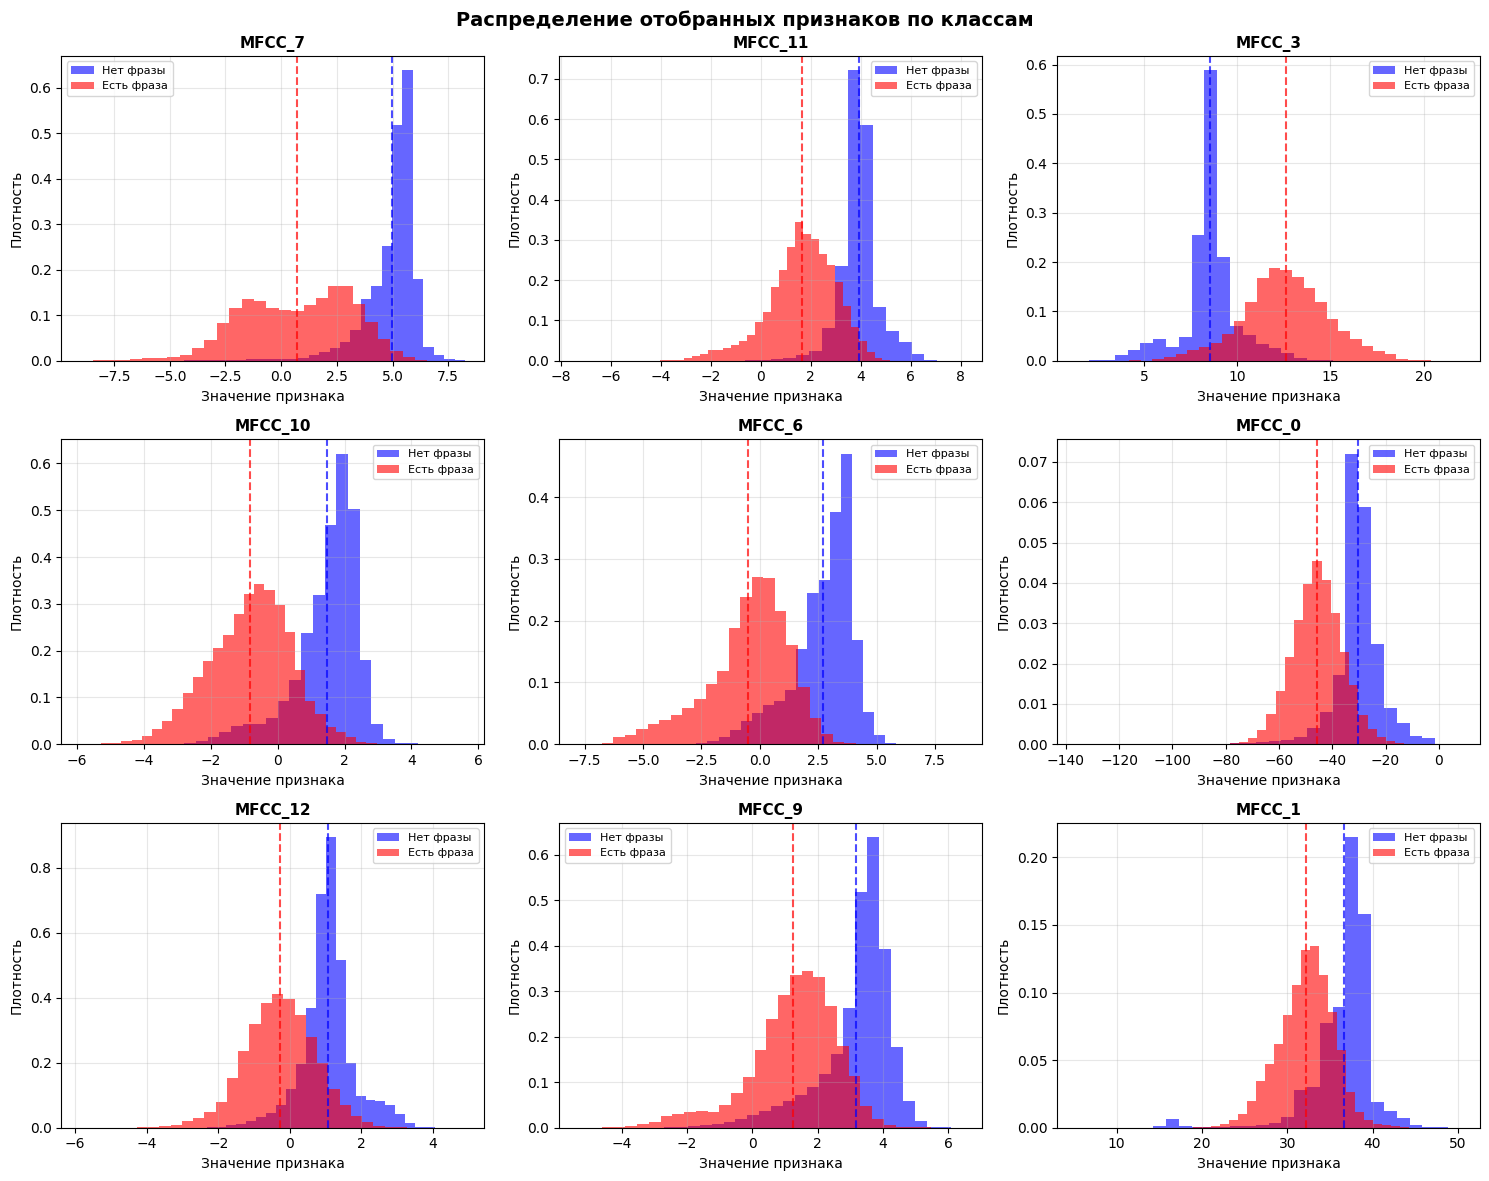


СТАТИСТИКА ВИЗУАЛИЗАЦИИ:
Всего признаков: 39
Отобрано признаков: 9
Сжатие: 23.1% от исходного размера


In [13]:
def visualize_selected_features(X_mean, labels, selected_indices, selected_names, save_path=None):
    """
    Визуализирует распределения отобранных признаков по классам для бинарной классификации
    
    Аргументы:
    - X_mean: усреднённые по времени признаки (n_samples, n_features)
    - labels: метки классов (0 или 1)
    - selected_indices: индексы отобранных признаков
    - selected_names: названия отобранных признаков
    - save_path: путь для сохранения графика (опционально)
    """
    unique_labels = np.unique(labels)
    n_total = len(selected_indices)
    n_cols = min(3, n_total)
    n_rows = int(np.ceil(n_total / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_total == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]
    axes = axes.flatten()
    
    class_names = {0: 'Нет фразы', 1: 'Есть фраза'}
    colors = ['blue', 'red']
    
    for k, (feat_idx, feat_name) in enumerate(zip(selected_indices, selected_names)):
        ax = axes[k]
        for j, label in enumerate(unique_labels):
            ax.hist(X_mean[labels == label, feat_idx], bins=30, alpha=0.6,
                   color=colors[j % len(colors)], 
                   label=class_names.get(label, str(label)), 
                   density=True)
            mean_val = X_mean[labels == label, feat_idx].mean()
            ax.axvline(mean_val, color=colors[j % len(colors)], 
                      linestyle='dashed', linewidth=1.5, alpha=0.7)
        
        ax.set_title(f'{feat_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Значение признака')
        ax.set_ylabel('Плотность')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    for ax in axes[n_total:]:
        ax.axis('off')  # скрытие неиспользуемых графиков
    
    plt.suptitle('Распределение отобранных признаков по классам', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"График сохранён: {save_path}")
    
    plt.show()


X_mean = np.mean(X_all, axis=1)  # Усредняем признаки по времени для визуализации

visualize_selected_features(
    X_mean, y_int, selected_indices, selected_names,
    save_path="D:/Аудио выборка/binary_selected_features_distribution.png"
)  # Визуализация распределений отобранных признаков


print("\n" + "="*60)
print("СТАТИСТИКА ВИЗУАЛИЗАЦИИ:")
print("="*60)
print(f"Всего признаков: {X_all.shape[2]}")
print(f"Отобрано признаков: {len(selected_indices)}")
print(f"Сжатие: {len(selected_indices)/X_all.shape[2]*100:.1f}% от исходного размера")